In [1]:
import pickle
import pandas as pd
import copy
import numpy as np
import ast


import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

from _helper_functions import cb
from _helper_functions import dprint

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# A function to get all single flips of an element

In [2]:
def get_all_single_orientation_flips(tfbsSeq):
    tfbsSeq=tfbsSeq.split('-')
    yield 'no flip','-'.join(tfbsSeq)
    
    # Iterate over all elements
    for idx,tfbs in enumerate(tfbsSeq):
        
        # skip if spacer
        if tfbs[0]=='L': continue
        
        # Flip orientation
        tfbs=list(tfbs)
        if tfbs[-1]=='F':
            tfbs[-1]='R'
        elif tfbs[-1]=='R':
            tfbs[-1]='F'
        tfbs=''.join(tfbs)
        
        outTfbsSeq=copy.deepcopy(tfbsSeq)
        outTfbsSeq[idx]=tfbs
        yield tfbsSeq[idx][:2],'-'.join(outTfbsSeq)
        

for i in get_all_single_orientation_flips('L5-G3R-L4-G2F-L3-E2R-L2-E1R-L1-G1F-L6'):
    print(i)

('no flip', 'L5-G3R-L4-G2F-L3-E2R-L2-E1R-L1-G1F-L6')
('G3', 'L5-G3F-L4-G2F-L3-E2R-L2-E1R-L1-G1F-L6')
('G2', 'L5-G3R-L4-G2R-L3-E2R-L2-E1R-L1-G1F-L6')
('E2', 'L5-G3R-L4-G2F-L3-E2F-L2-E1R-L1-G1F-L6')
('E1', 'L5-G3R-L4-G2F-L3-E2R-L2-E1F-L1-G1F-L6')
('G1', 'L5-G3R-L4-G2F-L3-E2R-L2-E1R-L1-G1R-L6')


# load mpra data

In [3]:
# Load all data
fn='01-Calculate-Enhancer-Activity-Levels/02-generated-tables/endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'
allDF=pd.read_pickle(fn).set_index('enhancer-sites',drop=True)
allDF.head()

,enhancer-id,wt-enhancer-seq,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
enhancer-sites,,,,,,,
L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,Otx-a WT,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0
L1-G1F-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,ORL351560,CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATT...,0.856235,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-1.100699,"(0, -1)",0
L1-G1R-L2-E1F-L3-E2F-L4-G2F-L5-G3F-L6,ORL108031,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,0.777169,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.706492,"(0, 0)",0
L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3R-L6,ORL414244,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,-1.486866,"(0, -1)",0
L1-G1R-L2-E1R-L3-E2F-L4-G2R-L5-G3F-L6,ORL280162,CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATT...,0.518839,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-1.322202,"(0, -1)",0


In [4]:
# load functional enhancers as 
funcDF=allDF.loc[allDF['enhancer-dependent-gata-ets']==1,:]
funcDF.head()

,enhancer-id,wt-enhancer-seq,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
enhancer-sites,,,,,,,
L1-G1F-L2-E1F-L3-E2F-L4-G2R-L5-G3R-L6,ORL373222,CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATT...,1.249433,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-0.258002,"(1, -1)",1
L1-G1F-L2-E1R-L3-E2F-L4-G2R-L5-G3F-L6,ORL317857,CATCTGAAGCTCGAGATAACTAACTTCCGTTTTCGAAAAGGAAATT...,1.375287,CATCTGAAGCTCGAAATAACTAACTTGCGTTTTCGAAAAGCAAATT...,NaN,"(1, -1)",1
L1-G1R-L2-E1R-L3-E2F-L4-G2F-L5-G3R-L6,ORL383871,CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATT...,1.614942,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-0.449367,"(1, -1)",1
L1-G1F-L2-E1R-L3-E2F-L4-G2F-L5-G3R-L6,ORL190541,CATCTGAAGCTCGAGATAACTAACTTCCGTTTTCGAAAAGGAAATT...,1.343622,CATCTGAAGCTCGAAATAACTAACTTGCGTTTTCGAAAAGCAAATT...,NaN,"(1, -1)",1
L1-G1F-L2-E1R-L3-E2R-L4-G2R-L5-G3R-L6,ORL200984,CATCTGAAGCTCGAGATAACTAACTTCCGTTTTCGAAATTTCCTTT...,1.336315,CATCTGAAGCTCGAAATAACTAACTTGCGTTTTCGAAATTTGCTTT...,NaN,"(1, -1)",1


In [6]:
allDF.head()

,enhancer-id,wt-enhancer-seq,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
enhancer-sites,,,,,,,
L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,Otx-a WT,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0
L1-G1F-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,ORL351560,CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATT...,0.856235,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-1.100699,"(0, -1)",0
L1-G1R-L2-E1F-L3-E2F-L4-G2F-L5-G3F-L6,ORL108031,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,0.777169,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.706492,"(0, 0)",0
L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3R-L6,ORL414244,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,-1.486866,"(0, -1)",0
L1-G1R-L2-E1R-L3-E2F-L4-G2R-L5-G3F-L6,ORL280162,CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATT...,0.518839,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-1.322202,"(0, -1)",0


# Load some ref data

In [8]:
fn='reference-files//OlsEnSeq2Id.pydict.pickle'
with open(fn,'rb') as f: OlsEnSeq2Id=pickle.load(f)
dprint(OlsEnSeq2Id)


CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA Otx-a WT


In [9]:
fn='reference-files//OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f: OLSEnSeq2Name=pickle.load(f)
dprint(OLSEnSeq2Name)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6


In [10]:
OLSName2Seq={v:k for k,v in OLSEnSeq2Name.items()}
dprint(OLSName2Seq)

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA


# Single flips that convert inert to active

In [12]:
# Get negative enhancers
thresholdToLabelPositives = 1
thresholdToLabelNegatives = 0

activityColumn='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'
ablColumn='abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

idxSet=set(allDF.index)

inertElementIdList=[]

for enID in allDF.index:
    
    activity=allDF.at[enID,activityColumn]
    
    if activity<=thresholdToLabelNegatives:
        inertElementIdList.append(enID)
    
print('num inert variants:',len(inertElementIdList))


num inert variants: 143799


In [13]:

enIdWithFunctionalFlips=[] # enhancer ids which can be converted from inert to neural with a single flip
beforeFlip=[] # activity before flip
afterFlip=[]  # activity after flip

numFuncVariantsDetected=0

numSingleFlipsPerSeq=[]
x=0

# keep track of how many gata/ets flips convert inert elements to active enhancers
tf2flips={'G':0,'E':0}
tfaff2flips={'G1':0,'G2':0,'G3':0,'E1':0,'E2':0}

c2v={c:[] for c in ['inert-seq','func-seq','inert-sites','func-sites','inert-activity','func-activity']}

for enID in inertElementIdList:
    
    x+=1
    
    beforeFlipActivity=allDF.at[enID,activityColumn]
    enSeq=allDF.at[enID,'wt-enhancer-seq']
    tfbsList=OLSEnSeq2Name[enSeq]
    
    #################################################################
    # Iterate through all single flips
    #################################################################
    
    IdList=[]
    dataActivity=[]
    
    
    for siteFlipped,variantTfbsList in get_all_single_orientation_flips(tfbsList):

        if siteFlipped=='no flip': continue

        en=OLSName2Seq[variantTfbsList]

            
        if variantTfbsList in allDF.index:

            activity   =allDF.at[variantTfbsList,activityColumn]
            activityAbl=allDF.at[variantTfbsList,ablColumn]
            
            # if abl not detected, assume 0
            if pd.isnull(activityAbl):
                activityAbl=0
            
            # Do not count variant if abl is funcitonal
            if activityAbl>thresholdToLabelPositives: 
                continue
            
            dataActivity.append((siteFlipped,activity,activityAbl))
            IdList.append(variantTfbsList)

        else: raise ValueError('enhancer not detected')
        
    # Check to see if any are confident positive requiring ABL==0
    activityOfFunctionalSingleFlips=[(siteFlipped,aWT) for siteFlipped,aWT,aABL in dataActivity if aWT>=thresholdToLabelPositives and aABL<=thresholdToLabelNegatives]
    numFuncVariantsDetected+=len(activityOfFunctionalSingleFlips)
    
    # print(dataActivity)
    
    if len(activityOfFunctionalSingleFlips)>0:
        
        enIdWithFunctionalFlips.append(enID)
        # print(enID)
        for siteFlipped,a in activityOfFunctionalSingleFlips:
            
            
            
            beforeFlip.append(beforeFlipActivity)
            afterFlip .append(a)
            
            tf2flips[siteFlipped[0]]+=1
            tfaff2flips[siteFlipped[:2]]+=1
            

            afterflipID=[]
            for site in enID.split('-'):
                if site[:2]==siteFlipped:
                    ori=site[2]
                    if ori=='F': afterflipID.append(site[:2]+"R")
                    if ori=='R': afterflipID.append(site[:2]+"F")
                else:
                    afterflipID.append(site)
                    

            afterflipID='-'.join(afterflipID)


            beforeseq=OLSName2Seq[enID]
            afterseq=OLSName2Seq[afterflipID]

            c2v['inert-seq'].append(beforeseq)
            c2v['func-seq'].append(afterseq)
            c2v['inert-sites'].append(enID)
            c2v['func-sites'].append(afterflipID)
            c2v['inert-activity'].append(allDF.at[enID,activityColumn])
            c2v['func-activity'].append(allDF.at[afterflipID,activityColumn])
            
        numSingleFlipsPerSeq.append(len(activityOfFunctionalSingleFlips))

    # break
print('done!')

done!


[Text(0, 0, 'before flip'), Text(1, 0, 'after flip')]

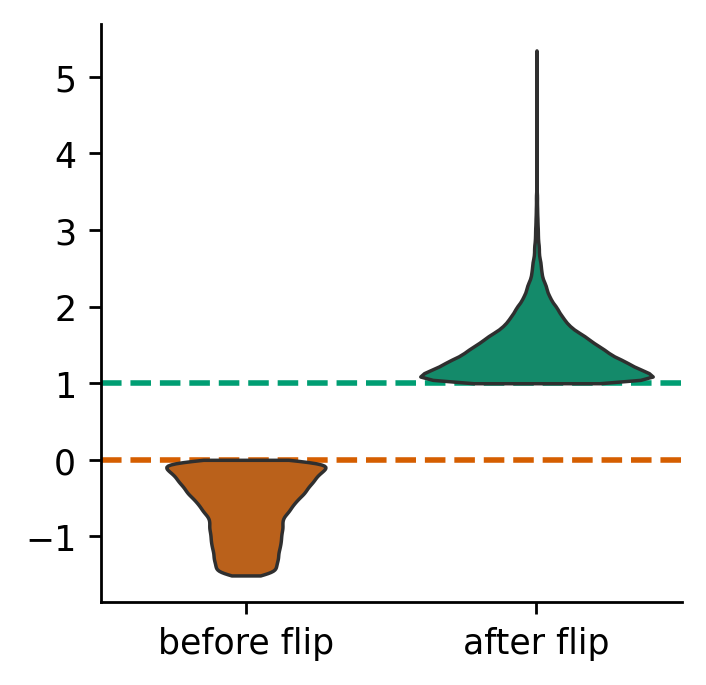

In [14]:
fig,ax=plt.subplots(1,figsize=(3,3),dpi=250)

lc=1

beforelist=[]
afterlist=[]
for before,after in zip(beforeFlip,afterFlip):
    lc+=1

    beforelist.append(before)
    afterlist.append(after)
    
    
sns.violinplot(data=[beforelist,afterlist],palette=[cb['red'],cb['green']],cut=0,inner=None,linewidth=1)
    
plt.axhline(thresholdToLabelPositives,color=cb['green'],ls='--',lw=1.6,zorder=0)
plt.axhline(thresholdToLabelNegatives,color=cb['red'],ls='--', lw=1.6,zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Enhancer Activity\n")
ax.set_xticks([0,1])

ax.set_ylabel('')
ax.set_xticklabels(['before flip','after flip'])
# ax.set_yticklabels([])



# effect of flip on syntax family

In [15]:
fn='reference-files/syntax-fam-Bin2Annotation.pydict.pickle'
with open(fn,'rb') as f: bin2anno=pickle.load(f)

In [16]:
fn='reference-files//OLSName2SyntaxFamily-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    OLSName2SyntaxFamily=pickle.load(f)
dprint(OLSName2SyntaxFamily)    

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6


In [17]:
fn='reference-files//SyntaxFamily2OLSName-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    SyntaxFamily2OLSName=pickle.load(f)
dprint(SyntaxFamily2OLSName)        

L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6 {'L1-G2R-L2-E1F-L3-E2F-L4-G3R-L5-G1F-L6', 'L1-G3R-L2-E2F-L3-E1F-L4-G2R-L5-G1F-L6', 'L1-G1R-L2-E2F-L3-E1F-L4-G3R-L5-G2F-L6', 'L1-G2R-L2-E1F-L3-E2F-L4-G1R-L5-G3F-L6', 'L1-G1R-L2-E2F-L3-E1F-L4-G2R-L5-G3F-L6', 'L1-G2R-L2-E2F-L3-E1F-L4-G1R-L5-G3F-L6', 'L1-G2R-L2-E2F-L3-E1F-L4-G3R-L5-G1F-L6', 'L1-G1R-L2-E1F-L3-E2F-L4-G3R-L5-G2F-L6', 'L1-G3R-L2-E1F-L3-E2F-L4-G2R-L5-G1F-L6', 'L1-G3R-L2-E2F-L3-E1F-L4-G1R-L5-G2F-L6', 'L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6', 'L1-G3R-L2-E1F-L3-E2F-L4-G1R-L5-G2F-L6'}


In [18]:
fn='reference-files//OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f:
    OLSEnSeq2Sites=pickle.load(f)

OLSSites2Seq={sites:seq for seq,sites in OLSEnSeq2Sites.items()}
dprint(OLSSites2Seq)

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA


In [19]:
OLSSeq2Sites={v:k for k,v in OLSSites2Seq.items()}
dprint(OLSSeq2Sites)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6


In [20]:
# load syntax family to bin location
fn='F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters=100.pd.df.pickle'
sdf=pd.read_pickle(fn).set_index('syntax-family',drop=False)
sdf.loc[:,'n-func-inert-tuple']=sdf.loc[:,'n-func-inert-tuple'].apply(lambda i: ast.literal_eval(i))
sdf=sdf.loc[:,'n-func-inert-tuple']
sdf.head(1)

syntax-family
L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6    (4, 2)
Name: n-func-inert-tuple, dtype: object

# How single flips impact syntax

In [23]:
# Get single flips which cause function
enIdWithFunctionalFlips=[]
beforeFlip=[] # activity before flip
afterFlip=[]  # activity after flip

numFuncVariantsDetected=0

numSingleFlipsPerSeq=[]
x=0

tf2flips={'G':0,'E':0}
tfaff2flips={'G1':0,'G2':0,'G3':0,'E1':0,'E2':0}

tfaff2affOfResultingEnhancer={'G1':[],'G2':[],'G3':[],'E1':[],'E2':[]}

synfam2tfaff2flips={sf:{k:v for k,v  in tfaff2flips.items()} for sf in ['Inert', 'Moderate', 'Robust','']}

sf2sf2tfaff2flips={sfi:{sfj:{k:v for k,v  in tfaff2flips.items()} for sfj in ['Inert', 'Moderate', 'Robust','']} for sfi in ['Inert', 'Moderate', 'Robust','']}

tfaff2syndeltas={'G1':[],'G2':[],'G3':[],'E1':[],'E2':[]}
sf2sf2tfaff2syndeltas={sfi:{sfj:{'G1':[],'G2':[],'G3':[],'E1':[],'E2':[]} for sfj in ['Inert', 'Moderate', 'Robust','Not Labeled']} for sfi in ['Inert', 'Moderate', 'Robust','Not Labeled']}

c2v={c:[] for c in ['start-sites','after-sites','site-flipped']}

flip2synbin2numflips={'before':{},'after':{}}

for enID in inertElementIdList:
    
    x+=1
    # if x%1000==0: print(x,end=', ')
    
    beforeFlipActivity=allDF.at[enID,activityColumn]
    enSeq=allDF.at[enID,'wt-enhancer-seq']
    tfbsList=OLSEnSeq2Name[enSeq]
    
    #################################################################
    # Iterate through all single flips
    #################################################################
    
    IdList=[]
    dataActivity=[]
    
    
    for siteFlipped,variantTfbsList in get_all_single_orientation_flips(tfbsList):
        
        if siteFlipped=='no flip': continue

        en=OLSName2Seq[variantTfbsList]

            
        if variantTfbsList in allDF.index:
            activity   =allDF.at[variantTfbsList,activityColumn]
            activityAbl=allDF.at[variantTfbsList,ablColumn]
            
            # if abl not detected, assume 0
            if pd.isnull(activityAbl):
                activityAbl=0
            
            # Do not count variant if abl is funcitonal
            if activityAbl>thresholdToLabelPositives: 
                continue
            
            dataActivity.append((siteFlipped,activity,activityAbl))
            IdList.append(variantTfbsList)

        else: raise ValueError('enhancer not detected')
        
    # Check to see if any are confident positive requiring ABL==0
    activityOfFunctionalSingleFlips=[(siteFlipped,aWT) for siteFlipped,aWT,aABL in dataActivity if aWT>=thresholdToLabelPositives and aABL<=thresholdToLabelNegatives]
    numFuncVariantsDetected+=len(activityOfFunctionalSingleFlips)
    
    # print(dataActivity)
    
    if len(activityOfFunctionalSingleFlips)>0:
        
        enIdWithFunctionalFlips.append(enID)
        for siteFlipped,a in activityOfFunctionalSingleFlips:
            
            
            
            beforeFlip.append(beforeFlipActivity)
            afterFlip .append(a)
            
            tf2flips[siteFlipped[0]]+=1
            tfaff2flips[siteFlipped[:2]]+=1
            
            tfaff2affOfResultingEnhancer[siteFlipped[:2]].append(a)
            
            # get syntax family annotation of the before flip
            synfam=OLSName2SyntaxFamily[enID]
            synbin=sdf[synfam]
            
            if synbin not in flip2synbin2numflips['before']:
                flip2synbin2numflips['before'][synbin]=0
            flip2synbin2numflips['before'][synbin]+=1
            
            if synbin in bin2anno: synanno=bin2anno[synbin]
            else:                  synanno='Not Labeled'
            
            synfam2tfaff2flips[synanno][siteFlipped[:2]]+=1

            # get syntax family annotation of the after flip
            afterflipID=[]
            for site in enID.split('-'):
                if site[:2]==siteFlipped:
                    ori=site[2]
                    if ori=='F': afterflipID.append(site[:2]+"R")
                    if ori=='R': afterflipID.append(site[:2]+"F")
                else:
                    afterflipID.append(site)
                    

            afterflipID='-'.join(afterflipID)
            aftersynfam=OLSName2SyntaxFamily[afterflipID]
            aftersynbin=sdf[aftersynfam]

            if aftersynbin not in flip2synbin2numflips['after']:
                flip2synbin2numflips['after'][aftersynbin]=0
            flip2synbin2numflips['after'][aftersynbin]+=1
            
            if aftersynbin in bin2anno: aftersynanno=bin2anno[aftersynbin]
            else:                       aftersynanno='Not Labeled'
            
            
            sf2sf2tfaff2flips[synanno][aftersynanno][siteFlipped[:2]]+=1
            
                        
            c2v['start-sites'].append(enID)
            c2v['after-sites'].append(afterflipID)
            # c2v['delta-ss'].append(deltasynscore)
            c2v['site-flipped'].append(siteFlipped)
            
            
            
            
        numSingleFlipsPerSeq.append(len(activityOfFunctionalSingleFlips))

        
    # break

print('done!')

done!


In [24]:
flipsdf=pd.DataFrame(c2v)
flipsdf.head()

,start-sites,after-sites,site-flipped
0,L1-G1F-L2-E1R-L3-E2R-L4-G2R-L5-G3F-L6,L1-G1F-L2-E1R-L3-E2F-L4-G2R-L5-G3F-L6,E2
1,L1-G1F-L2-E1R-L3-E2R-L4-G2R-L5-G3F-L6,L1-G1F-L2-E1R-L3-E2R-L4-G2R-L5-G3R-L6,G3
2,L1-G1R-L2-E1R-L3-E2R-L4-G2R-L5-G3R-L6,L1-G1F-L2-E1R-L3-E2R-L4-G2R-L5-G3R-L6,G1
3,L1-G1R-L2-E1F-L3-E2R-L5-G2R-L4-G3F-L6,L1-G1F-L2-E1F-L3-E2R-L5-G2R-L4-G3F-L6,G1
4,L1-G1R-L2-E1F-L3-E2R-L5-G2R-L4-G3F-L6,L1-G1R-L2-E1F-L3-E2R-L5-G2F-L4-G3F-L6,G2


In [25]:
allDF.head(1)

,enhancer-id,wt-enhancer-seq,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
enhancer-sites,,,,,,,
L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,Otx-a WT,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0


# FigS9b: Single flips move elements into more robust families

In [27]:
zmin=0
zmax=0

for fliptimepoint in flip2synbin2numflips:
    for sbi in flip2synbin2numflips[fliptimepoint]:
        n=flip2synbin2numflips[fliptimepoint][sbi]
        if n>zmax:
            zmax=n

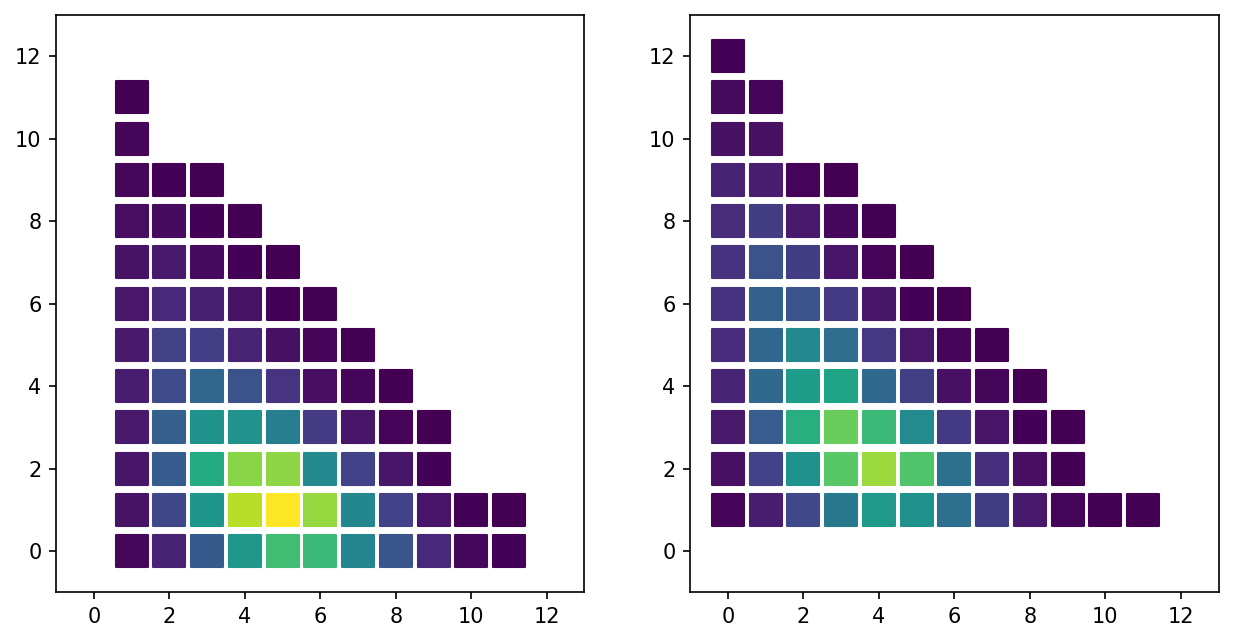

In [28]:
fig,ax=plt.subplots(1,2,figsize=(10,5),dpi=150)

for axi,fliptimepoint in enumerate(['before','after']):
    
    for y,x in flip2synbin2numflips[fliptimepoint]:
        
        n=flip2synbin2numflips[fliptimepoint][y,x]
        
        ax[axi].scatter(x,y,c=n,vmin=zmin,vmax=zmax,marker='s',s=230)
    
    ax[axi].set_ylim(-1,13)
    ax[axi].set_xlim(-1,13)
        


Text(0.5, 0, 'Number of Inert Sequences')

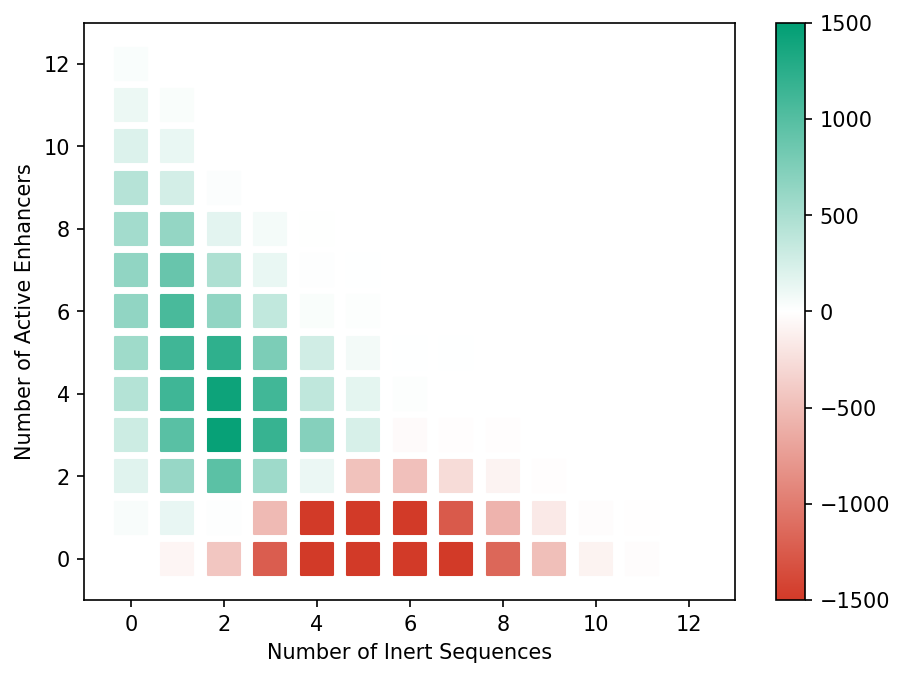

In [29]:

allDeltas=[]

cbar=True

fig,ax=plt.subplots(1,figsize=(7,5),dpi=150)

yx_spots_all=set(flip2synbin2numflips['before'].keys()) | set(flip2synbin2numflips['after'].keys())

cmap_name = 'custom_colormap'
colors = [cb['orangenature'], 'white', cb['green']]
n_bins = 1000  # Number of bins for the colormap

cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

for y,x in yx_spots_all:

    if (y,x) in flip2synbin2numflips['before']: nb=flip2synbin2numflips['before'][y,x]
    else:                                       nb=0

    if (y,x) in flip2synbin2numflips['after']:  na=flip2synbin2numflips['after'][y,x]
    else:                                       na=0

    delta=na-nb
    allDeltas.append((delta,x,y))

    mappable=ax.scatter(x,y,c=delta,vmin=-1500,vmax=1500,marker='s',s=250,cmap=cm)

if cbar:
    fig.colorbar(mappable, orientation='vertical')        

ax.set_ylim(-1,13)
ax.set_xlim(-1,13)

ax.set_ylabel('Number of Active Enhancers')
ax.set_xlabel('Number of Inert Sequences')
